# demo

This notebook demonstrates how you can use `stac-cog-xarray` to lazily load massive arrays of Level 2 data from STAC metadata with cloud-optimized geotiff assets.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import stac_cog_xarray

Define the area of interest with a CRS and a bounding box.

In [2]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:5070"
dst_bbox = (-150_000, 2_500_000, 600_000, 3_000_000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

Query a STAC API and cache the result to a local stac-geoparquet file using `rustac`. This file will be used by the `stac-cog-xarray` backend to determine which COGs are required for which array operations.

This example generates an archive of Sentinel 2 Level 2A items for the month of June 2025 for an area that covers a large part of Minnesota, USA.

In [3]:
items_parquet = "/tmp/items.parquet"

if not Path(items_parquet).exists():
    await rustac.search_to(
        items_parquet,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-06-01/2025-06-30",
        bbox=bbox_4326,
        limit=100,
    )

Open a 100% lazy `DataArray` representation of the assets referenced in the stac-geoparquet file for your specified CRS and bounding box and resolution. 

In [4]:
da = await stac_cog_xarray.open_async(
    items_parquet,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=100,
    time_period="P1D",
    bands=["red", "green", "blue"],
    dtype="int16",
)

da

<xarray.DataArray (band: 3, time: 30, y: 5000, x: 7500)> Size: 7GB
[3375000000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
  * y        (y) float64 40kB 2.5e+06 2.5e+06 2.5e+06 ... 3e+06 3e+06 3e+06
  * x        (x) float64 60kB -1.5e+05 -1.498e+05 -1.498e+05 ... 5.998e+05 6e+05

Get all of the values for a single point. Add `chunk(time=1)` to parallelize across time coordinates.

In [5]:
%%time
da.chunk(time=1).sel(x=299965, y=2653947, method="nearest").compute()

CPU times: user 58 s, sys: 6.16 s, total: 1min 4s
Wall time: 12.7 s


<xarray.DataArray (band: 3, time: 30)> Size: 180B
array([[    0,  2401,     0,  2450,     0, 10204,  2305,     0, 11972,
            0,     0,  8694,     0,  8674,     0,     0,  3526,     0,
        11815,     0,     0,  8288,     0,  2338,     0,  8155, 11156,
            0,  2371,     0],
       [    0,  2325,     0,  2318,     0, 10313,  2220,     0, 12910,
            0,     0,  8988,     0,  8427,     0,     0,  3565,     0,
        12537,     0,     0,  8400,     0,  2232,     0,  8063, 11271,
            0,  2358,     0],
       [    0,  2197,     0,  2138,     0, 10779,  2028,     0, 14624,
            0,     0,  9418,     0,  8392,     0,     0,  3418,     0,
        13905,     0,     0,  8836,     0,  2027,     0,  8020, 11703,
            0,  2159,     0]], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
    y        float64 8B 2.654e+06
    x        float64 8B 3e+05

Select a spatial subset

In [6]:
subset = da.sel(
    x=slice(100_000, 400_000),
    y=slice(2_600_000, 2_800_000),
)
subset

<xarray.DataArray (band: 3, time: 30, y: 2000, x: 3000)> Size: 1GB
[540000000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
  * y        (y) float64 16kB 2.6e+06 2.6e+06 2.6e+06 ... 2.8e+06 2.8e+06
  * x        (x) float64 24kB 1e+05 1.002e+05 1.002e+05 ... 3.998e+05 4e+05

Extract the values for a single point

In [10]:
%%time
subset.isel(time=1, x=0, y=0).compute()

CPU times: user 2.01 s, sys: 220 ms, total: 2.23 s
Wall time: 3.54 s


<xarray.DataArray (band: 3)> Size: 6B
array([1690, 1920, 1661], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
    time     datetime64[s] 8B 2025-06-02
    y        float64 8B 2.6e+06
    x        float64 8B 1e+05

Load the spatial subset array for a single time coordinate and plot it.

CPU times: user 1min 4s, sys: 2.2 s, total: 1min 6s
Wall time: 1min 5s


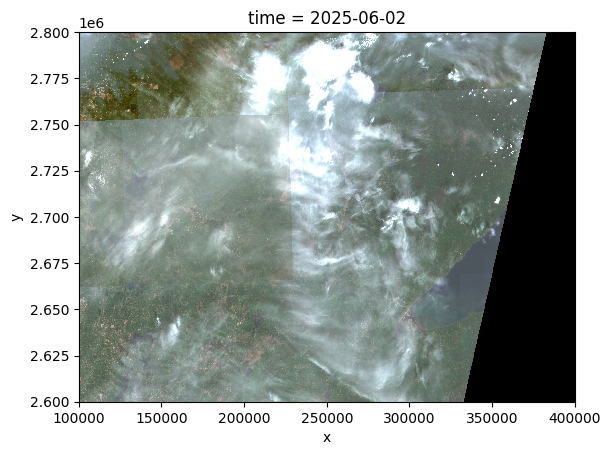

In [6]:
%%time
subset.isel(time=1).plot.imshow(rgb="band", vmin=0, vmax=4000)

Add some parallelism with `dask` by specifying chunks for each dimension

CPU times: user 1min 13s, sys: 7.47 s, total: 1min 20s
Wall time: 20.9 s


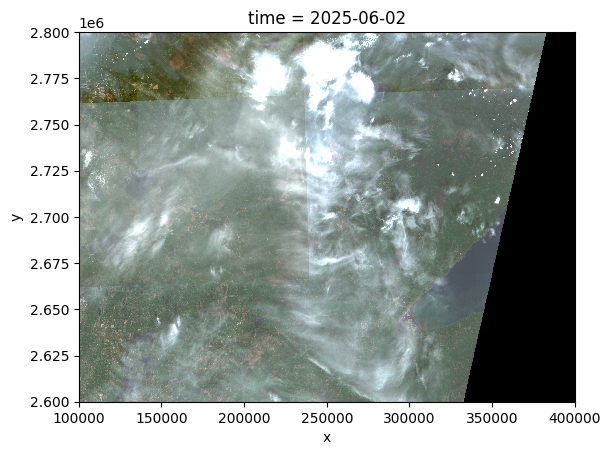

In [7]:
%%time
(
    subset.isel(time=1)
    .chunk(band=1, x=512, y=512)
    .plot.imshow(rgb="band", vmin=0, vmax=4000)
)